<a href="https://colab.research.google.com/github/MadhusudhanReddy717/Cognitive-Computing-Projects/blob/main/AI-Powered%20Job%20Candidate%20Screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please enter at least 3 candidates.

Enter candidate name (or type 'done' to finish): Madhu
Enter resume details for Madhu: python, ML, Java
Was Madhu hired? (1 for Yes, 0 for No): 1
Enter candidate name (or type 'done' to finish): done

❌ You have entered only 1 candidate(s). Please enter at least 3 total.

Enter candidate name (or type 'done' to finish): Siva
Enter resume details for Siva: python, Java
Was Siva hired? (1 for Yes, 0 for No): 1
Enter candidate name (or type 'done' to finish): Konda
Enter resume details for Konda: ServiceNow, Pubg, FreeFire
Was Konda hired? (1 for Yes, 0 for No): 0
Enter candidate name (or type 'done' to finish): Nag
Enter resume details for Nag: Java, Javascript, React, Python
Was Nag hired? (1 for Yes, 0 for No): 1
Enter candidate name (or type 'done' to finish): done

✅ Entered Data:
  Candidate                           Resume  Hired
0     Madhu                 python, ML, Java      1
1      Siva                     python, Java      1
2     Konda  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


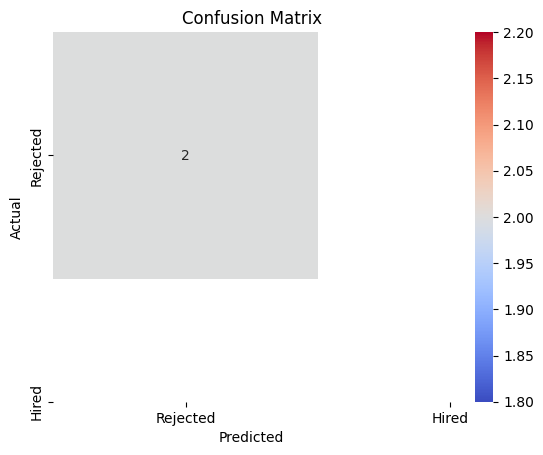

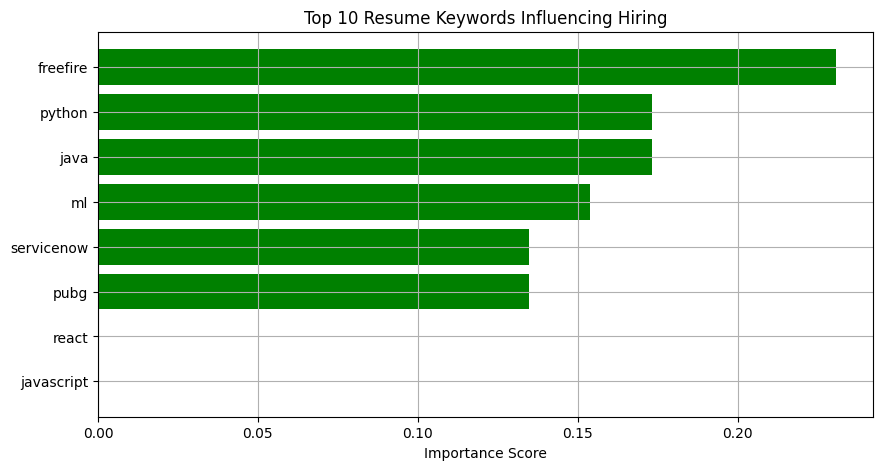

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

def get_user_input(min_samples=3):
    candidates = []
    resumes = []
    hired = []

    print(f"Please enter at least {min_samples} candidates.\n")

    while True:
        name = input("Enter candidate name (or type 'done' to finish): ")
        if name.lower() == 'done':
            if len(candidates) < min_samples:
                print(f"\n❌ You have entered only {len(candidates)} candidate(s). Please enter at least {min_samples} total.\n")
                continue
            else:
                break

        resume = input(f"Enter resume details for {name}: ")
        hire_status = input(f"Was {name} hired? (1 for Yes, 0 for No): ")

        candidates.append(name)
        resumes.append(resume)
        hired.append(int(hire_status))

    data = {
        'Candidate': candidates,
        'Resume': resumes,
        'Hired': hired
    }
    return pd.DataFrame(data)

df = get_user_input(min_samples=3)

print("\n✅ Entered Data:")
print(df)

# Proceed with train-test split
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['Resume'])
y = df['Hired']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=['Rejected', 'Hired'], yticklabels=['Rejected', 'Hired'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

importances = model.feature_importances_
features = vectorizer.get_feature_names_out()
top_indices = np.argsort(importances)[-10:]
top_features = [features[i] for i in top_indices]
top_scores = importances[top_indices]

plt.figure(figsize=(10, 5))
plt.barh(top_features, top_scores, color='green')
plt.xlabel("Importance Score")
plt.title("Top 10 Resume Keywords Influencing Hiring")
plt.grid(True)
plt.show()
